In [3]:
import xarray as xr
import tifffile
import numpy as np
import glob, os, gc
import pandas as pd
import scanpy as sc
import vima

# Define functions

In [11]:
# write multi-channel tiff for CANVAS
def prep_canvas(datadir, outpath):
    print("Preparing data for CANVAS")
    
    files = glob.glob(f'{datadir}/10u/counts/*.nc')
    outdir = f'{outpath}/canvas/data/raw_data'
    os.makedirs(f'{outdir}', exist_ok=True)  
    os.makedirs(f'{outdir}/image_files', exist_ok=True)
    os.makedirs(f'{outdir}/../../configs/preprocess', exist_ok=True)

    for f in files:
        name = os.path.splitext(os.path.basename(f))[0].replace('.', '-')
        d = xr.open_dataarray(f)
        avgchannel = d.mean(dim="marker")
        avg_channel_expanded = avgchannel.expand_dims(dim={"marker": ["avg"]})
        d = xr.concat([d, avg_channel_expanded], dim="marker")

        # Save marker values to a text file
        with open(f"{outdir}/image_files/{name}.txt", "w") as txt_file:
            for marker in d.marker.values:
                txt_file.write(f"{marker}\n")

        # Save as a multi-channel TIFF
        arr = d.values  # shape (Y, X, channel)
        arr_tiff = np.transpose(arr, (2, 0, 1))  # shape (channel, Y, X)
        tifffile.imwrite(f"{outdir}/image_files/{name}.tif", arr_tiff)

    infile = glob.glob(f'{outdir}/image_files/*.txt')[0]
    outfile1 = f'{outdir}/common_channels.txt'
    outfile2 = f'{outdir}/../../configs/preprocess/channels_vis_strength.yaml'

    with open(infile, "r") as infile, open(outfile1, "w") as of1, open(outfile2, "w") as of2:
        for line in infile:
            of1.write(line)
            of2.write(line.strip() + ": 1\n")

In [12]:
# cells file for UTAG, CellCharter, and TissueMosaic
# produce an AnnData object that is cells x markers, with obs containing a column named sid and a column named cid
def prep_cells(cellspath, outpath, sid_name, cellid_name):
    print("Preparing Cells file")
    d = sc.read(cellspath)
    d = d[~d.obs.duplicated(subset=[sid_name, cellid_name], keep='first')]
    d.obs.rename(columns={sid_name: 'sid', cellid_name: 'cid'}, inplace=True)
    d.write(f'{outpath}/cells.h5ad')

    sc.pp.normalize_total(d, target_sum=np.median(d.X.sum(axis=1)))
    sc.pp.log1p(d)
    sc.tl.pca(d)
    allcells_pca = d.obs
    pcs = [f'PC{i+1}' for i in range(d.obsm['X_pca'].shape[1])]
    for pc, col in zip(pcs, d.obsm['X_pca'].T):
        allcells_pca[pc] = col
    harmpcs = vima.pp.harmonize(allcells_pca, '/Users/yakir/miniconda3/envs/Renv/bin/Rscript')
    d.obsm['X_pca'] = harmpcs[pcs].values
    d.write(f'{outpath}/cells_harm.h5ad')

In [ ]:
# Sample-specific AnnData files, including one-hot-encoded cell types in adata.obsm, for TissueMosaic
def prep_sample_ads(cells_path, metadata_path, subclass_name, outpath): 
    print("Preparing sample-specific AnnData objects")
    d = sc.read_h5ad(cellspath)
    meta_join_key = d.obs["Donor ID"].astype(str) + "_" + d.obs["sid"].astype(str) + "_" + d.obs["cid"].astype(str)
    d.obs['meta_join_key'] = meta_join_key 

    metadata = pd.read_csv(metadatapath, sep='\t')
    d.obs = d.obs.join(metadata[['x', 'y', subclass_name]], on='meta_join_key') 
    d.obs.rename({subclass_name: 'cell_type'}, inplace=True, axis=1)
    d = d[~d.obs.cell_type.isna()]
    d.obsm['cell_type'] = pd.get_dummies(d.obs.cell_type)

    for sid in d.obs['Specimen Barcode'].unique(): 
        subset = d[d.obs['Specimen Barcode'] == sid]
        subset.uns['status'] = 0 if subset.obs['Overall AD neuropathological Change'].unique()[0] == 'Not AD' else 1 
        d.write_h5ad(f'{outpath}/{subset.obs["Donor ID"][0]}_{sid}.h5ad') 

In [4]:
# 100u spots file for STAGATE
def prep_spots100u(datadir, filename_parser, outpath):
    print("Preparing Spots file")
    
    # read in data and make into visium-sized spots
    files = glob.glob(f'{datadir}/10u/counts/*.nc')

    def downsample(data, sid, donor):
        y, x, c = data.shape
        new_y, new_x = y // 10, x // 10
        downsampled = data.data[:new_y * 10, :new_x * 10, :].reshape(new_y, 10, new_x, 10, c).sum(axis=(1, 3))
        y_coords = data.coords['y'][np.arange(0, new_y*10, 10)]
        x_coords = data.coords['x'][np.arange(0, new_x*10, 10)]
        
        downsampled = downsampled.reshape(-1, c)
        df = pd.DataFrame(downsampled, columns=data.coords['marker'].values)
        df['y_microns'] = np.repeat(y_coords, new_x)
        df['x_microns'] = np.tile(x_coords, new_y)
        df['sid'] = sid
        df['donor'] = donor
        return df

    samples = []
    for f in files:
        print('.', end='')
        s = xr.open_dataarray(f).astype(np.float32)
        s.attrs.update(filename_parser(f))
        samples.append(downsample(s, s.attrs['sid'], s.attrs['donor']))
    gc.collect()

    samples = pd.concat(samples)
    probes = samples.columns[:-4]
    genes = [g for g in probes if 'Blank' not in g]
    metadata = ['sid','donor', 'x_microns','y_microns']
    samples = samples[metadata + genes]

    # remove spots with few transcripts
    samples = samples[samples[genes].sum(axis=1) >= 500]
    samples.reset_index(inplace=True, drop=True)

    # create anndata object
    d = sc.AnnData(X=samples[genes],
                obs=samples[metadata],
                var=pd.DataFrame(index=genes))
    d.obsm['spatial'] = samples[['x_microns','y_microns']].values
    d.uns['spatial'] = samples[['x_microns','y_microns']].values

    # qc
    sc.pp.normalize_total(d, target_sum=np.median(d.X.sum(axis=1)))
    sc.pp.log1p(d)

    #save
    d.write(f'{outpath}/100u_spots.h5ad')

In [ ]:
# create patch-level average metamarker profile and cell type abundnace profile
def add_cellcounts(d, cells, types):
    for sid in d.obs.sid.unique():
        print(sid, end='|')
        mycells = cells[cells.sid == sid]
        mypatches = d.obs[d.obs.sid == sid]
        cellcounts = pd.concat([
                mycells[(mycells.sid == sid)&(mycells.x >= x)&(mycells.x <= x+10*ps)&(mycells.y >= y)&(mycells.y <= y+10*ps)][types].value_counts()
                for sid,x,y,ps in mypatches[['sid','x_microns','y_microns', 'patchsize']].values
            ], axis=1).T.fillna(0)
        columns = cellcounts.columns.values
        d.obs.loc[d.obs.sid == sid, columns] = cellcounts.values
    d.obs['totalcells'] = d.obs[columns].sum(axis=1).values
    d.uns['celltypes'] = columns

def prep_patch_reps(datadir, filename_parser, cellspath, celltype_name, outpath):
    # read in samples
    repname = 'pca_k=10_harmony'
    samples = vima.read_samples(f'{datadir}/10u/{repname}/*.nc', filename_parser)

    # create patches
    P = vima.PatchCollection(samples) # this line may not be needed
    Pdense = vima.PatchCollection(samples, max_frac_empty=0.5, sid_nums=P.sid_nums)
    print(len(Pdense), 'dense patches')

    # create avg meta-marker profiles
    Pdense.numpy_mode()
    d = sc.AnnData(
        X=Pdense[:][0].mean(axis=(1,2)),
        obs=Pdense.meta)
    sc.pp.neighbors(d, use_rep='X')
    sc.tl.umap(d)
    sc.tl.leiden(d, resolution=1, key_added='leiden1')
    d.write(f'{outpath}/patches_avgmm.h5ad')
    print('done creating avg mm profiles')

    # create cell type abundance profiles
    cells = pd.read_csv(cellspath, sep='\t')
    cells['sid'] = cells.Section.str.split('_').str[1]

    add_cellcounts(d, cells, celltype_name)
    d = sc.AnnData(
        X=np.nan_to_num(d.obs[d.uns['celltypes']].values / d.obs.totalcells.values[:,None]),
        obs=d.obs,
        var=pd.DataFrame(index=pd.Series(d.uns['celltypes'], name='celltype')))
    sc.pp.neighbors(d, use_rep='X')
    sc.tl.umap(d)
    sc.tl.leiden(d, resolution=1, key_added='leiden1')
    d.write(f'{outpath}/patches_celltypeabundance.h5ad')

# Run

Preparing Cells file


/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/scanpy/preprocessing/_normalization.py:206: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


=== running harmony ===


Loading required package: Rcpp
code for methods in class “Rcpp_harmony” was not checked for suspicious field assignments (recommended package ‘codetools’ not available?)
code for methods in class “Rcpp_harmony” was not checked for suspicious field assignments (recommended package ‘codetools’ not available?)

Attaching package: ‘arrow’

The following object is masked from ‘package:utils’:

    timestamp



harmonizing
metadata names: sid 


Transposing data matrix
Initializing state using k-means centroids initialization
Harmony 1/10
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
Harmony 2/10
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
Harmony 3/10
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|---

writing  /var/folders/w_/x2_v44_93nq_b3svp199t1rw0000gn/T/tmpqq23bre3_harmony.feather 
=== finished running harmony ===


/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


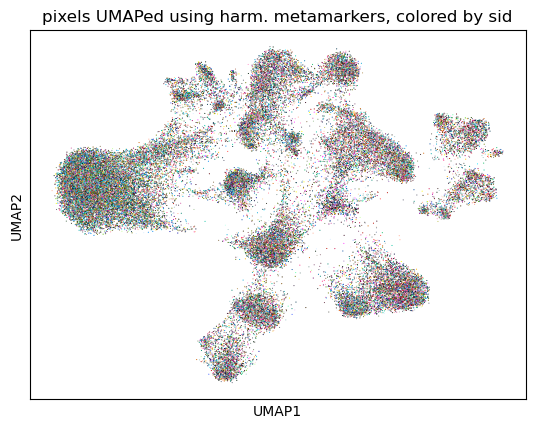

In [ ]:
def alz_filename_parser(fname):
    fname = os.path.splitext(os.path.basename(fname))[0]
    return {
        'donor': fname.split('_')[0],
        'sid': fname.split('_')[1]
    }
datadir = '../../ALZ/alz-data'
outpath = '_data/ALZ'

prep_cells(f'{datadir}/SEAAD_MTG_MERFISH.2024-12-11.h5ad', outpath,
           'Specimen Barcode', 'Cell ID')
prep_canvas(datadir, outpath)
prep_sample_ads(f'{datadir}/cells.h5ad', 
                f'{datadir}/SEAAD_MTG_MERFISH_metadata.2024-05-03.noblanks.harmonized.txt', 
                'subclass_name', 
                f'{outpath}/sample_ads') 
prep_spots100u(datadir, alz_filename_parser, outpath)
prep_patch_reps(datadir, alz_filename_parser,
                f'{datadir}/SEAAD_MTG_MERFISH_metadata.2024-05-03.noblanks.harmonized.txt',
                'subclass_name', outpath)

# UC